In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


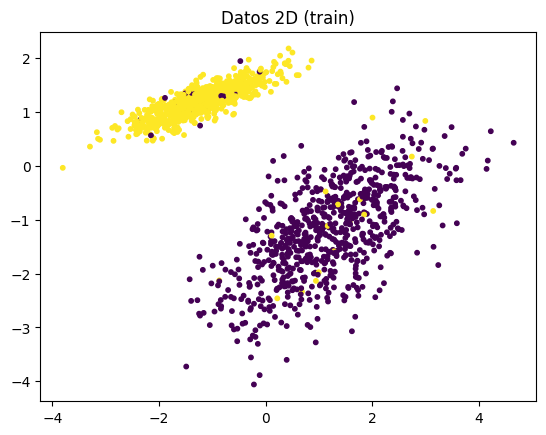

In [2]:
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.05,
    random_state=7
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

plt.figure()
plt.scatter(X_train[:,0], X_train[:,1], s=10, c=y_train)
plt.title("Datos 2D (train)")
plt.show()


In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=7,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("accuracy test =", accuracy_score(y_test, y_pred))
print("oob_score     =", rf.oob_score_)


accuracy test = 0.978
oob_score     = 0.9746666666666667


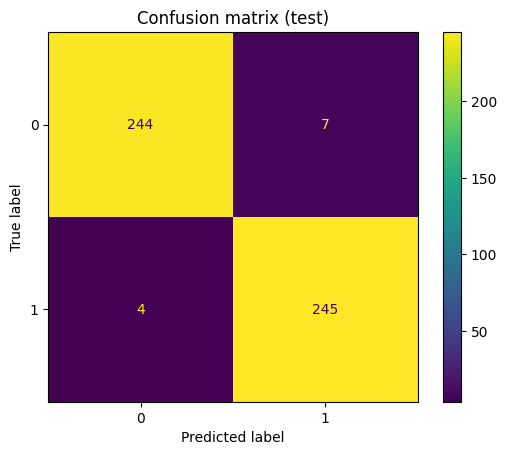

In [4]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion matrix (test)")
plt.show()


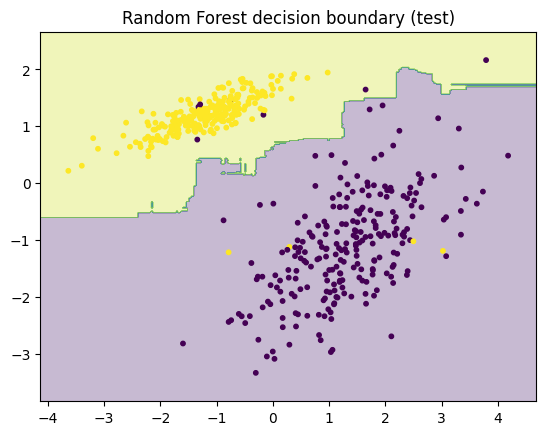

In [5]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, zz, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
    plt.title(title)
    plt.show()

plot_decision_boundary(rf, X_test, y_test, "Random Forest decision boundary (test)")


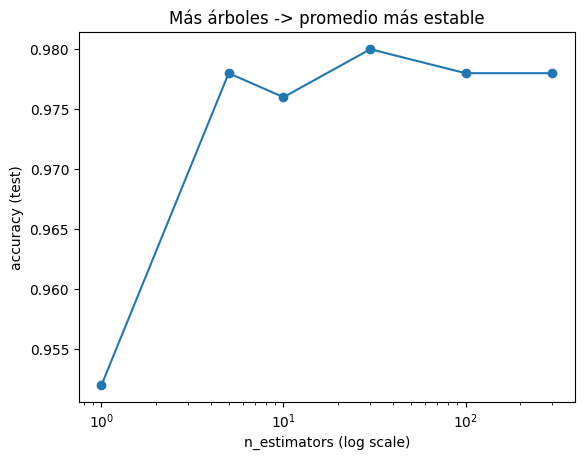

1 trees: 0.952
5 trees: 0.978
10 trees: 0.976
30 trees: 0.98
100 trees: 0.978
300 trees: 0.978


In [6]:
trees_list = [1, 5, 10, 30, 100, 300]
accs = []

for n_trees in trees_list:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        random_state=7,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(trees_list, accs, marker="o")
plt.xscale("log")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("accuracy (test)")
plt.title("Más árboles -> promedio más estable")
plt.show()

for n_trees, acc in zip(trees_list, accs):
    print(n_trees, "trees:", acc)


# Breast Cancer dataset

In [17]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=690,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=7,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("accuracy test =", accuracy_score(y_test, y_pred))
print("oob_score_    =", rf.oob_score_)


accuracy test = 0.972027972027972
oob_score_    = 0.9624413145539906


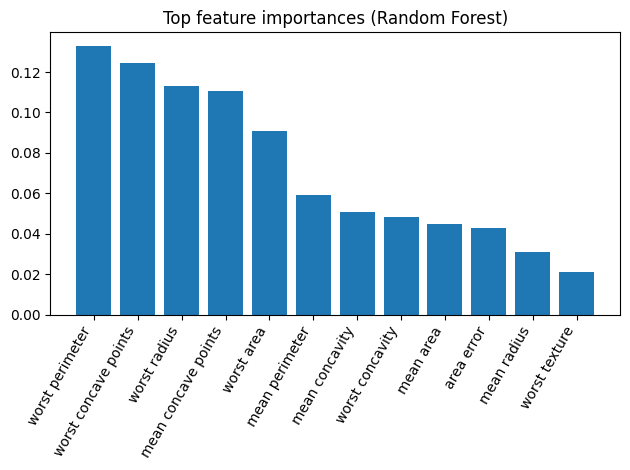

worst perimeter : 0.13299138833403853
worst concave points : 0.12469698980881107
worst radius : 0.1131948528250796
mean concave points : 0.1107425965745773
worst area : 0.091039840671665
mean perimeter : 0.05938354981020384
mean concavity : 0.050537795058471495
worst concavity : 0.048257514393711926
mean area : 0.04478353505078096
area error : 0.042822959968884945
mean radius : 0.030714059166748218
worst texture : 0.02113310594726286


In [8]:
imp = rf.feature_importances_
order = np.argsort(imp)[::-1]

top_k = 12
top_idx = order[:top_k]

plt.figure()
plt.bar(range(top_k), imp[top_idx])
plt.xticks(range(top_k), feature_names[top_idx], rotation=60, ha="right")
plt.title("Top feature importances (Random Forest)")
plt.tight_layout()
plt.show()

for i in top_idx:
    print(feature_names[i], ":", imp[i])
